# Zadanie 1

| Task | Description |
|------|-------------|
| hia_hou | Absorption |
| bioavailability_ma | Absorption |
| bbb_martins | Distribution |

In [4]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
df = df[df['task'].isin(['hia_hou', 'bioavailability_ma', 'bbb_martins'])]
df['task']


C:\Users\kopcz\admet\TODO\zadanie1\michal


0       bioavailability_ma
1       bioavailability_ma
2       bioavailability_ma
3       bioavailability_ma
4       bioavailability_ma
               ...        
4461           bbb_martins
4462           bbb_martins
4463           bbb_martins
4464           bbb_martins
4465           bbb_martins
Name: task, Length: 3248, dtype: object

In [5]:
df.head()

,smiles,label,task,split,dipole,homo_lumo,electrons,energy,mask_1,mask_2,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,OCC(S)CS,0.0,bioavailability_ma,train,2.271,8.548,38.0,-49.84415,1,1,...,0,0,0,0,0,0,0,0,0,0
1,CC[N+](C)(C)c1cccc(O)c1,0.0,bioavailability_ma,train,9.426,0.000,0.0,5.49013,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,0.0,bioavailability_ma,train,4.655,8.522,102.0,-110.83064,1,1,...,0,0,0,0,0,0,0,0,0,0
3,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)CC#N)[...,0.0,bioavailability_ma,train,2.768,8.465,122.0,-181.56000,1,1,...,1,0,0,0,0,0,0,0,0,0
4,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](C(=O)O)c3ccsc3...,0.0,bioavailability_ma,train,3.933,8.487,134.0,-206.72786,1,1,...,1,0,0,0,0,0,0,1,0,0


In [10]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

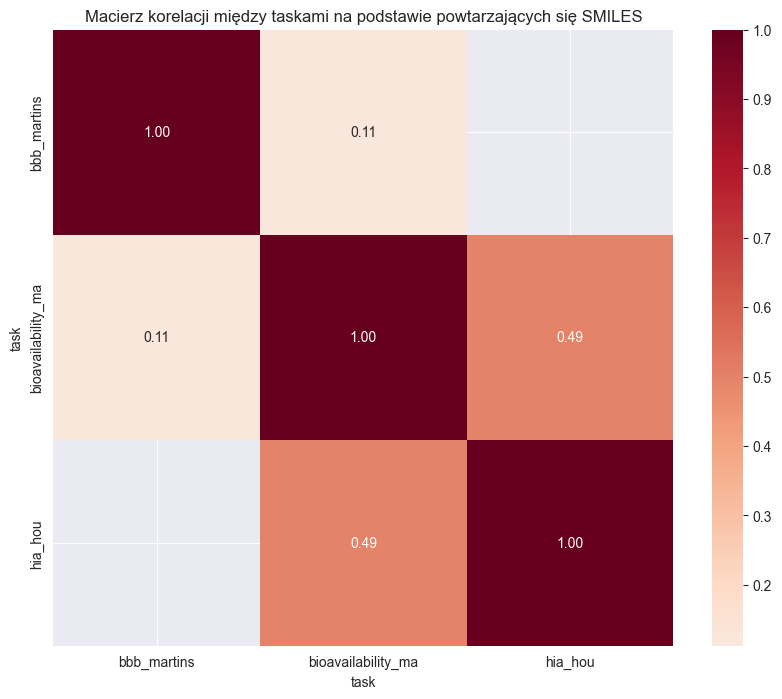

In [9]:
df_wide = df.pivot_table(index='smiles', columns='task', values='label')
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

Brak powtarzających się smiles bbb_martins i hia_hou

In [8]:
corr_matrix

task,bbb_martins,bioavailability_ma,hia_hou
task,,,
bbb_martins,1.000000,0.112274,NaN
bioavailability_ma,0.112274,1.000000,0.494045
hia_hou,NaN,0.494045,1.000000
